<div align="center">

# Universidad de Sevilla  
## Grado en Ingeniería del Software  
### Escuela Técnica Superior de Ingeniería Informática  
### Inteligencia Artificial (IA) – Curso 2025/2026  

<img src="../../img/portada.png" width="300"/>

---

#  Aprendizaje automático relacional  
### Primera Convocatoria – Junio 2026  

**Profesor:** Pedro Almagro Blanco

**Autores:**  
David Espina Apellaniz  
Marco Padilla Gómez  

**Fecha de entrega:** 8 de Junio de 2025  

</div>

# 01 - Exploración inicial del dataset Twitch ES

En este notebook se realiza el análisis exploratorio inicial del dataset **Twitch Social Networks - ES**.

El objetivo es entender:
- qué información contiene cada archivo;
- cuántos nodos y aristas hay;
- cómo está distribuida la variable objetivo `mature`;
- si el dataset es adecuado para una tarea de clasificación relacional de nodos.


## 1. Importación de librerías y configuración inicial

In [1]:
import sys
from pathlib import Path

import json
import pandas as pd
import matplotlib.pyplot as plt

# Permite importar módulos desde la carpeta src cuando el notebook está dentro de subcarpetas
sys.path.append("../../")

from src.data_loader import load_edges, load_target, load_json_features
from src.graph_features import build_graph, get_graph_summary

DATA_RAW_PATH = Path("../../data/raw")
IMG_PATH = Path("../../img")
IMG_PATH.mkdir(parents=True, exist_ok=True)


## 2. Carga de los archivos originales

Se cargan los tres archivos principales del dataset:

- `ES_edges.csv`: relaciones entre usuarios.
- `ES_target.csv`: información de cada usuario y variable objetivo.
- `ES_features.json`: características adicionales asociadas a cada usuario.


In [2]:
edges = load_edges(DATA_RAW_PATH / "ES_edges.csv")
target = load_target(DATA_RAW_PATH / "ES_target.csv")
features_json = load_json_features(DATA_RAW_PATH / "ES_features.json")

print("Edges shape:", edges.shape)
print("Target shape:", target.shape)
print("Número de nodos en JSON:", len(features_json))


Edges shape: (59382, 2)
Target shape: (4648, 6)
Número de nodos en JSON: 4648


## 3. Vista inicial de los datos

In [3]:
edges.head()

,from,to
0,0,1819
1,0,2840
2,1,1565
3,1,1309
4,1,1397


In [4]:
target.head()

,id,days,mature,views,partner,new_id
0,68458707,1522,False,4405,False,3558
1,133928858,768,False,164810,True,3372
2,46892468,1895,False,4953,False,818
3,128745923,828,True,12262,False,236
4,84422595,1317,False,4937,False,2255


In [5]:
# Ejemplo de las primeras entradas del JSON
list(features_json.items())[:5]

[('1412',
  [89,
   166,
   1040,
   846,
   2987,
   1649,
   920,
   224,
   3097,
   400,
   569,
   822,
   2362,
   802,
   2728,
   2734]),
 ('3032',
  [515,
   1943,
   289,
   3084,
   1575,
   3164,
   920,
   224,
   3097,
   400,
   1391,
   635,
   569,
   821,
   2645,
   1147,
   440]),
 ('4032',
  [1948,
   421,
   586,
   202,
   2024,
   846,
   45,
   3164,
   920,
   224,
   2798,
   2064,
   2534,
   139,
   2664,
   2362]),
 ('3945',
  [438,
   2464,
   967,
   861,
   152,
   1649,
   920,
   1907,
   2185,
   2986,
   1607,
   1895,
   1013,
   928,
   569,
   139,
   608,
   2362,
   802,
   1530,
   1028,
   1147,
   763,
   2734,
   82]),
 ('949',
  [2598, 1713, 1053, 2928, 473, 846, 920, 224, 3097, 706, 1525, 2912, 2362])]

## 4. Información general del dataset

In [6]:
print("Columnas de ES_edges.csv:")
print(edges.columns.tolist())

print("\nColumnas de ES_target.csv:")
print(target.columns.tolist())

print("\nTipos de datos de target:")
print(target.dtypes)


Columnas de ES_edges.csv:
['from', 'to']

Columnas de ES_target.csv:
['id', 'days', 'mature', 'views', 'partner', 'new_id']

Tipos de datos de target:
id         int64
days       int64
mature      bool
views      int64
partner     bool
new_id     int64
dtype: object


## 5. Análisis básico del grafo

A partir del archivo de aristas se construye el grafo. En este trabajo, cada nodo representa un usuario de Twitch y cada arista representa una relación entre usuarios.


In [7]:
graph = build_graph(edges)
summary = get_graph_summary(graph)

summary

{'num_nodes': 4648,
 'num_edges': 59382,
 'density': 0.005498522726893927,
 'is_connected': True,
 'num_connected_components': 1,
 'largest_component_size': 4648}

In [8]:
print(f"Número de nodos: {summary['num_nodes']}")
print(f"Número de aristas: {summary['num_edges']}")
print(f"Densidad del grafo: {summary['density']:.6f}")
print(f"¿Es conexo?: {summary['is_connected']}")
print(f"Número de componentes conexas: {summary['num_connected_components']}")
print(f"Tamaño de la mayor componente conexa: {summary['largest_component_size']}")


Número de nodos: 4648
Número de aristas: 59382
Densidad del grafo: 0.005499
¿Es conexo?: True
Número de componentes conexas: 1
Tamaño de la mayor componente conexa: 4648


## 6. Análisis de la variable objetivo `mature`

La variable `mature` será la variable que se quiere predecir. Se plantea como una tarea de clasificación binaria:

- `True`: canal marcado como contenido mature.
- `False`: canal no marcado como mature.


In [9]:
target["mature"].value_counts()

mature
False    3288
True     1360
Name: count, dtype: int64

In [10]:
target["mature"].value_counts(normalize=True) * 100

mature
False    70.740103
True     29.259897
Name: proportion, dtype: float64

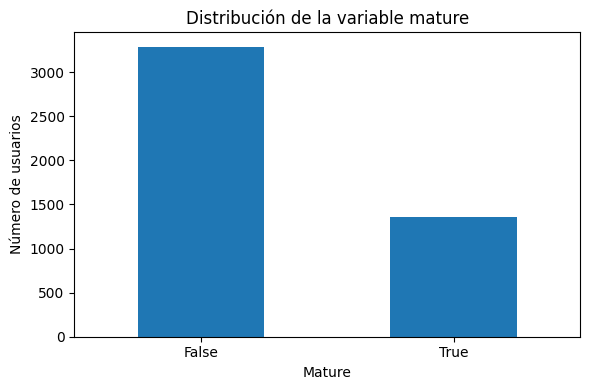

In [11]:
mature_counts = target["mature"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
mature_counts.plot(kind="bar")
plt.title("Distribución de la variable mature")
plt.xlabel("Mature")
plt.ylabel("Número de usuarios")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(IMG_PATH / "distribucion_mature.png")
plt.show()


## 7. Análisis de variables numéricas disponibles

Además de las métricas relacionales que se calcularán más adelante, el archivo `ES_target.csv` contiene variables como:

- `days`: antigüedad o días asociados al usuario.
- `views`: número de visualizaciones.


In [12]:
target[["days", "views"]].describe()

,days,views
count,4648.000000,4.648000e+03
mean,1341.602625,1.032367e+05
std,648.824912,8.852851e+05
min,118.000000,8.000000e+00
25%,830.000000,1.532750e+03
50%,1323.500000,4.404500e+03
75%,1799.250000,1.509250e+04
max,4083.000000,3.054557e+07


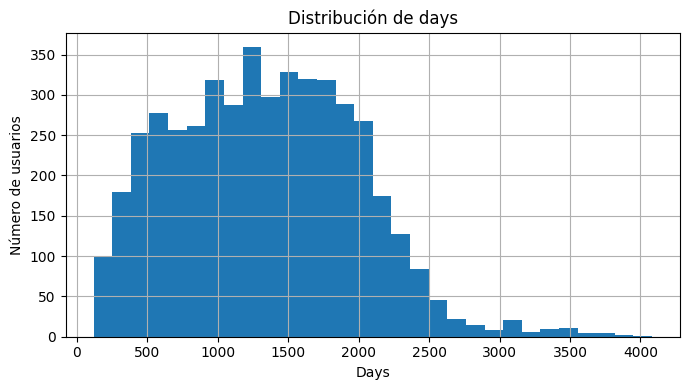

In [13]:
plt.figure(figsize=(7, 4))
target["days"].hist(bins=30)
plt.title("Distribución de days")
plt.xlabel("Days")
plt.ylabel("Número de usuarios")
plt.tight_layout()
plt.savefig(IMG_PATH / "distribucion_days.png")
plt.show()


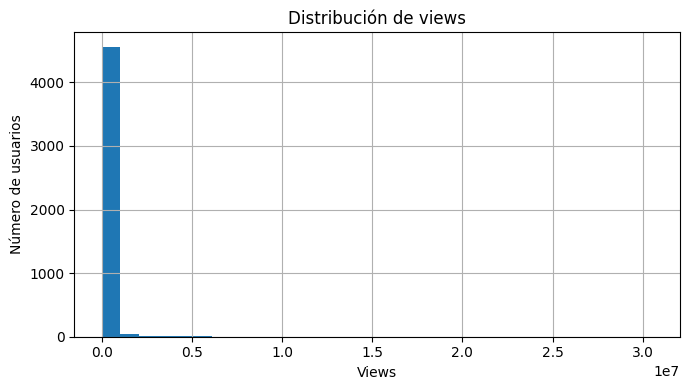

In [14]:
plt.figure(figsize=(7, 4))
target["views"].hist(bins=30)
plt.title("Distribución de views")
plt.xlabel("Views")
plt.ylabel("Número de usuarios")
plt.tight_layout()
plt.savefig(IMG_PATH / "distribucion_views.png")
plt.show()


## 8. Análisis del archivo JSON de características

El archivo `ES_features.json` contiene una lista de características para cada nodo. Para mantener el trabajo sencillo y evitar crear demasiadas columnas, se usará inicialmente una variable llamada `num_features`, que representa el número de características asociadas a cada usuario.


In [15]:
json_lengths = pd.Series({int(node_id): len(values) for node_id, values in features_json.items()})
json_lengths.describe()

count    4648.000000
mean       19.390921
std         6.053856
min         9.000000
25%        15.000000
50%        18.000000
75%        22.000000
max        77.000000
dtype: float64

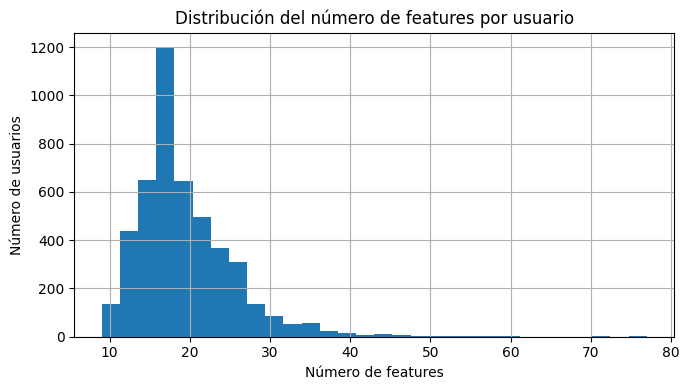

In [16]:
plt.figure(figsize=(7, 4))
json_lengths.hist(bins=30)
plt.title("Distribución del número de features por usuario")
plt.xlabel("Número de features")
plt.ylabel("Número de usuarios")
plt.tight_layout()
plt.savefig(IMG_PATH / "distribucion_num_features.png")
plt.show()


## 9. Comprobación de correspondencia entre nodos

Se comprueba si los identificadores `new_id` del archivo `ES_target.csv` aparecen en el grafo y en el JSON.


In [17]:
graph_nodes = set(graph.nodes())
target_nodes = set(target["new_id"])
json_nodes = set(int(node_id) for node_id in features_json.keys())

print("Nodos en grafo:", len(graph_nodes))
print("Nodos en target:", len(target_nodes))
print("Nodos en JSON:", len(json_nodes))

print("\nNodos de target que no están en grafo:", len(target_nodes - graph_nodes))
print("Nodos de grafo que no están en target:", len(graph_nodes - target_nodes))
print("Nodos de target que no están en JSON:", len(target_nodes - json_nodes))


Nodos en grafo: 4648
Nodos en target: 4648
Nodos en JSON: 4648

Nodos de target que no están en grafo: 0
Nodos de grafo que no están en target: 0
Nodos de target que no están en JSON: 0


## 10. Conclusiones iniciales

Conclusiones que se pueden usar posteriormente en la memoria:

- El dataset puede representarse como un grafo, donde los nodos son usuarios de Twitch y las aristas son relaciones entre ellos.
- La variable objetivo seleccionada es `mature`, por lo que el problema se formula como una clasificación binaria de nodos.
- El dataset contiene información relacional, procedente del grafo, y atributos adicionales de los usuarios.
- En el siguiente notebook se calcularán métricas relacionales como grado, centralidad, PageRank, clustering, betweenness y comunidades.
